# CorePromoter model clean workflow

This notebook is a simplified version of Model_CorePromoter_v0.ipynb. It keeps the core workflow only:

1. setup and utilities
2. training-data assembly
3. model definition
4. train/test split and training
5. train/test evaluation
6. trained filter logos
7. NN-based assembled-sequence scan

BPM scanning and old debug cells are intentionally removed.


In [1]:
## Setup
import os
import random
import itertools
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

import logomaker
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

from util import getPFM, Motif2Seqs, sci_ticks

SEED = 777

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## Utility functions

These helper functions are shared by training and scan cells.


In [2]:
def stratified_sample(df, col, counts, seed=SEED):
    df = df.copy()
    rng_bins = pd.cut(df[col], bins=len(counts))
    parts = []
    for grp, cnt in zip(sorted(rng_bins.dropna().unique()), counts):
        sub = df[rng_bins == grp]
        if len(sub) == 0:
            continue
        parts.append(sub.sample(cnt, replace=True, random_state=seed))
    return pd.concat(parts)


def dna_one_hot(seq, flatten=False):
    mapping = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        '-': [-1, -1, -1, -1],
        'N': [1/4, 1/4, 1/4, 1/4],
    }
    one_hot = np.array([mapping.get(base, [0, 0, 0, 0]) for base in seq.upper()]).T
    return one_hot.flatten() if flatten else one_hot


## Build training dataset

The dataframe name is kept as `df_train` for compatibility, but it represents the full sampled dataset before train/test split.


In [3]:
TABLE_DIR = "../tables"
LIBRARY_ORDER = ["PL17", "SL16", "SL17", "SL18", "DL", "UL", "ITS"]


def PpurR(seq):
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCAC' + seq[:6] + 'TTTTCGTCAAGATCGGC' + seq[-6:] + 'TCCACGCTTACTAAATCTATGT'


def SL16(seq):
    return 'ACAGCAGCAGTCAGGTACTCCAGTAAATGCTTGACT' + seq + 'TATTATGCACACCCCTAAATCTATGTAG'


def SL17(seq):
    return 'CACAGCAGCAGTCAGGTACTCCAGTCCACTTGACC' + seq + 'TAACCTTCCACGCTTACTAAATCTATGT'


def SL18(seq):
    return 'TCTTCACACAGCAGCTCAGGTACTCAGGCTTTACA' + seq + 'GATAATGTGTGGAATTAAATCTATGTA'


def DL(seq):
    return 'AGCAGCAGTCAGGTACTCCAGTAAATGCTTGCCCGCCGCGTGATTCGTGTTATAAC' + seq + 'CAAAATCTATGTAGCT'


def UL(seq):
    return 'CAGAAAAAG' + seq + 'GGCTTGCGGCTTTTGCCGCTTTTTTTTACCCTGCACACCCCT----------'


def ITS(seq):
    return 'AGCAGCGTTAAATTCACGCCCTTCTCTTGAGACATTTCTTTTGCACTGGTAAACTAAATC' + seq + 'GTCCCAGGCT'


def build_training_dataframe():
    df_PL17 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/PL.pkl"), 'LogGFP', [2000, 2000, 2000, 1000, 1000, 1000, 500, 500])[['rep1', 'rep2', 'LogGFP']]
    df_PL17['Sequence'] = df_PL17.index.map(PpurR)
    df_PL17['Library'] = "PL17"

    df_SL16 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/SL16.pkl"), 'LogGFP', [300] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_SL16['Sequence'] = df_SL16.index.map(SL16)
    df_SL16['Library'] = "SL16"

    df_SL17 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/SL17.pkl"), 'LogGFP', [400] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_SL17['Sequence'] = df_SL17.index.map(SL17)
    df_SL17['Library'] = "SL17"

    df_SL18 = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/SL18.pkl"), 'LogGFP', [300] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_SL18['Sequence'] = df_SL18.index.map(SL18)
    df_SL18['Library'] = "SL18"

    df_DL = stratified_sample(pd.read_pickle(f"{TABLE_DIR}/DL.pkl"), 'LogGFP', [200] * 10)[['rep1', 'rep2', 'LogGFP']]
    df_DL['Sequence'] = df_DL.index.map(DL)
    df_DL['Library'] = "DL"

    df_UL = pd.read_pickle(f"{TABLE_DIR}/UL.pkl")
    df_UL = df_UL[(df_UL['LogGFP'] > 1) & (df_UL['LogGFP'] < 4)]
    df_UL = stratified_sample(df_UL, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])[['rep1', 'rep2', 'LogGFP']]
    df_UL['Sequence'] = df_UL.index.map(UL)
    df_UL['Library'] = "UL"

    df_ITS = pd.read_pickle(f"{TABLE_DIR}/ITS.pkl")
    df_ITS = stratified_sample(df_ITS, 'LogGFP', [500, 1000, 1500, 1500, 1000, 500])[['rep1', 'rep2', 'LogGFP']]
    df_ITS['Sequence'] = df_ITS.index.map(ITS)
    df_ITS['Library'] = "ITS"

    return pd.concat([df_PL17, df_SL16, df_SL17, df_SL18, df_DL, df_UL, df_ITS]).reset_index(drop=True)


df_train = build_training_dataframe()
print(df_train.shape)
display(df_train.groupby('Library').size().reindex(LIBRARY_ORDER))
df_train.head()


(34000, 5)


Library
PL17    10000
SL16     3000
SL17     4000
SL18     3000
DL       2000
UL       6000
ITS      6000
dtype: int64

,rep1,rep2,LogGFP,Sequence,Library
0,0.446169,0.409302,0.427736,CACAGCAGCAGTCAGGTACTCCAGTCCACACATATTTTTCGTCAAG...,PL17
1,0.622179,0.467092,0.544635,CACAGCAGCAGTCAGGTACTCCAGTCCACGGAACATTTTCGTCAAG...,PL17
2,0.502947,NaN,0.502947,CACAGCAGCAGTCAGGTACTCCAGTCCACATATGTTTTTCGTCAAG...,PL17
3,0.664487,0.406002,0.535245,CACAGCAGCAGTCAGGTACTCCAGTCCACATAAGATTTTCGTCAAG...,PL17
4,0.545845,NaN,0.545845,CACAGCAGCAGTCAGGTACTCCAGTCCACGTTAGGTTTTCGTCAAG...,PL17


## Model definition

The model keeps the original structure: 8 first-layer filters and 3 architecture channels for spacer flexibility.


In [4]:
class DNAFunctionPredictor(nn.Module):
    def __init__(self, seq_length, num_conds):
        super().__init__()
        self.seq_length = seq_length
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=8, stride=1)
        self._initialize_conv1()

        self.conv2 = nn.Conv1d(in_channels=8, out_channels=3, kernel_size=65, stride=1)
        self._initialize_conv2()

        self.conds_bias = nn.Parameter(torch.zeros(num_conds))
        self.param_max = nn.Parameter(torch.tensor(np.log(1000.0)), requires_grad=True)
        self.param_min = nn.Parameter(torch.tensor(np.log(0.5)), requires_grad=True)
        self.param_e0 = nn.Parameter(torch.tensor(0.0), requires_grad=True)

    def _initialize_conv1(self):
        motifs = [
            "AAAATTTG",
            "GAAAATAG",
            "TTGACATT",
            "NGGCCTAA",
            "ATGGGGTA",
            "TAATTTTT",
            "AAAGCAAA",
            "AAAAAGNN",
        ]
        custom_weights = np.stack([
            getPFM(Motif2Seqs(motif), ratios=True).values.T for motif in motifs
        ], axis=0)
        self.conv1.weight = nn.Parameter(torch.tensor(custom_weights, dtype=torch.float32), requires_grad=True)
        self.conv1.bias.data.zero_()
        self.conv1.bias.requires_grad = False

    def _initialize_conv2(self):
        filter1_weights = np.zeros((8, 65))
        filter2_weights = np.zeros((8, 65))
        filter3_weights = np.zeros((8, 65))

        filter1_weights[0, 3], filter1_weights[1, 11], filter1_weights[2, 22], filter1_weights[3, 30], filter1_weights[4, 38], filter1_weights[5, 46], filter1_weights[6, 54], filter1_weights[7, 62] = 1, 1, 1, 1, 1, 1, 1, 1
        filter2_weights[0, 3], filter2_weights[1, 11], filter2_weights[2, 22], filter2_weights[3, 31], filter2_weights[4, 39], filter2_weights[5, 47], filter2_weights[6, 55], filter2_weights[7, 63] = 1, 1, 1, 1, 1, 1, 1, 1
        filter3_weights[0, 3], filter3_weights[1, 11], filter3_weights[2, 22], filter3_weights[3, 32], filter3_weights[4, 40], filter3_weights[5, 48], filter3_weights[6, 56], filter3_weights[7, 64] = 1, 1, 1, 1, 1, 1, 1, 1

        custom_weights = np.stack([filter1_weights, filter2_weights, filter3_weights], axis=0)
        self.conv2.weight.data = torch.tensor(custom_weights, dtype=torch.float32)
        self.conv2.weight.requires_grad = False
        self.conv2.bias.data.zero_()
        self.conv2.bias.requires_grad = True

    def energy(self, dna_seq):
        x = self.conv1(dna_seq)
        x = self.conv2(x)
        return torch.max(x.reshape(x.size(0), -1), dim=1, keepdim=True).values

    def energy2expression(self, x):
        beta = 1 / (0.001987 * 310)
        boltz_weight = torch.exp(beta * (x + self.param_e0))
        max_expr = torch.exp(self.param_max)
        min_expr = torch.exp(self.param_min)
        return torch.log(min_expr + max_expr * boltz_weight / (1 + boltz_weight))

    def forward(self, dna_seq, conds):
        x = self.energy(dna_seq)
        x = x + torch.matmul(conds, self.conds_bias.unsqueeze(1))
        return self.energy2expression(x)


## Train/test split and tensors


In [5]:
TEST_SIZE = 0.2
STRATIFY_BY_LIBRARY = False
BATCH_SIZE = 512

library_categorical = pd.Categorical(df_train['Library'], categories=LIBRARY_ORDER)
conds = pd.get_dummies(library_categorical).to_numpy(dtype=np.float32)
dna_seq = np.array(list(df_train['Sequence'].apply(dna_one_hot)), dtype=np.float32)
target_loge = (df_train['LogGFP'].values * np.log(10)).astype(np.float32)
libraries = df_train['Library'].values
indices = np.arange(len(df_train))

stratify_labels = libraries if STRATIFY_BY_LIBRARY else None
split = train_test_split(
    dna_seq, conds, target_loge, libraries, indices,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=stratify_labels,
)
(
    X_train_seq_np, X_test_seq_np,
    X_train_conds_np, X_test_conds_np,
    y_train_np, y_test_np,
    library_train, library_test,
    idx_train, idx_test,
) = split

X_train_seq = torch.tensor(X_train_seq_np, dtype=torch.float32, device=device)
X_train_conds = torch.tensor(X_train_conds_np, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.float32, device=device).unsqueeze(1)

X_test_seq = torch.tensor(X_test_seq_np, dtype=torch.float32, device=device)
X_test_conds = torch.tensor(X_test_conds_np, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test_np, dtype=torch.float32, device=device).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_seq, X_train_conds, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_seq, X_test_conds, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(X_train_seq):,}; Test: {len(X_test_seq):,}; Sequence length: {dna_seq.shape[2]}")


Train: 27,200; Test: 6,800; Sequence length: 80


## Training


In [6]:
seq_length = dna_seq.shape[2]
num_conds = conds.shape[1]
model = DNAFunctionPredictor(seq_length=seq_length, num_conds=num_conds).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

EPOCHS = 50
USE_TENSORBOARD = False
TENSORBOARD_LOG_DIR = "runs/20250628_CorePromoter_clean"
writer = SummaryWriter(TENSORBOARD_LOG_DIR) if USE_TENSORBOARD else None
history = []

for epoch in range(EPOCHS):
    model.train()
    for seq_batch, cond_batch, target_batch in train_loader:
        optimizer.zero_grad()
        output = model(seq_batch, cond_batch)
        loss = criterion(output, target_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(X_train_seq, X_train_conds) / np.log(10), y_train / np.log(10)).item()
        test_loss = criterion(model(X_test_seq, X_test_conds) / np.log(10), y_test / np.log(10)).item()

    history.append({'epoch': epoch + 1, 'train_mse_log10': train_loss, 'test_mse_log10': test_loss})
    if writer is not None:
        writer.add_scalars('Loss', {'Training Loss': train_loss, 'Testing Loss': test_loss}, epoch + 1)
    print(f"Epoch [{epoch + 1:02d}/{EPOCHS}] - Train MSE: {train_loss:.4f}, Test MSE: {test_loss:.4f}")

if writer is not None:
    writer.close()

history_df = pd.DataFrame(history)
display(history_df.tail())


Epoch [01/50] - Train MSE: 2.0722, Test MSE: 2.0375
Epoch [02/50] - Train MSE: 2.0140, Test MSE: 1.9800
Epoch [03/50] - Train MSE: 1.9575, Test MSE: 1.9242
Epoch [04/50] - Train MSE: 1.9025, Test MSE: 1.8699
Epoch [05/50] - Train MSE: 1.8490, Test MSE: 1.8170
Epoch [06/50] - Train MSE: 1.7970, Test MSE: 1.7657
Epoch [07/50] - Train MSE: 1.7464, Test MSE: 1.7157
Epoch [08/50] - Train MSE: 1.6972, Test MSE: 1.6672
Epoch [09/50] - Train MSE: 1.6496, Test MSE: 1.6202
Epoch [10/50] - Train MSE: 1.6032, Test MSE: 1.5745
Epoch [11/50] - Train MSE: 1.5582, Test MSE: 1.5301
Epoch [12/50] - Train MSE: 1.4663, Test MSE: 1.4375
Epoch [13/50] - Train MSE: 0.3277, Test MSE: 0.3295
Epoch [14/50] - Train MSE: 0.2945, Test MSE: 0.2991
Epoch [15/50] - Train MSE: 0.2779, Test MSE: 0.2819
Epoch [16/50] - Train MSE: 0.2650, Test MSE: 0.2700
Epoch [17/50] - Train MSE: 0.2537, Test MSE: 0.2590
Epoch [18/50] - Train MSE: 0.2442, Test MSE: 0.2491
Epoch [19/50] - Train MSE: 0.2366, Test MSE: 0.2428
Epoch [20/50

,epoch,train_mse_log10,test_mse_log10
45,46,0.170027,0.174284
46,47,0.169722,0.174117
47,48,0.168652,0.172591
48,49,0.167836,0.171662
49,50,0.167238,0.171361


## Train/test evaluation

Metrics are reported on the LogGFP log10 scale.


Train/Test prediction metrics


,split,n,mse_log10,rmse_log10,mae_log10,pearson_r,spearman_rho,r2,residual_mean,residual_sd
0,train,27200,0.1672,0.4089,0.3197,0.8042,0.8029,0.6451,-0.0217,0.4084
1,test,6800,0.1714,0.4140,0.3232,0.8016,0.8017,0.6384,-0.0420,0.4118


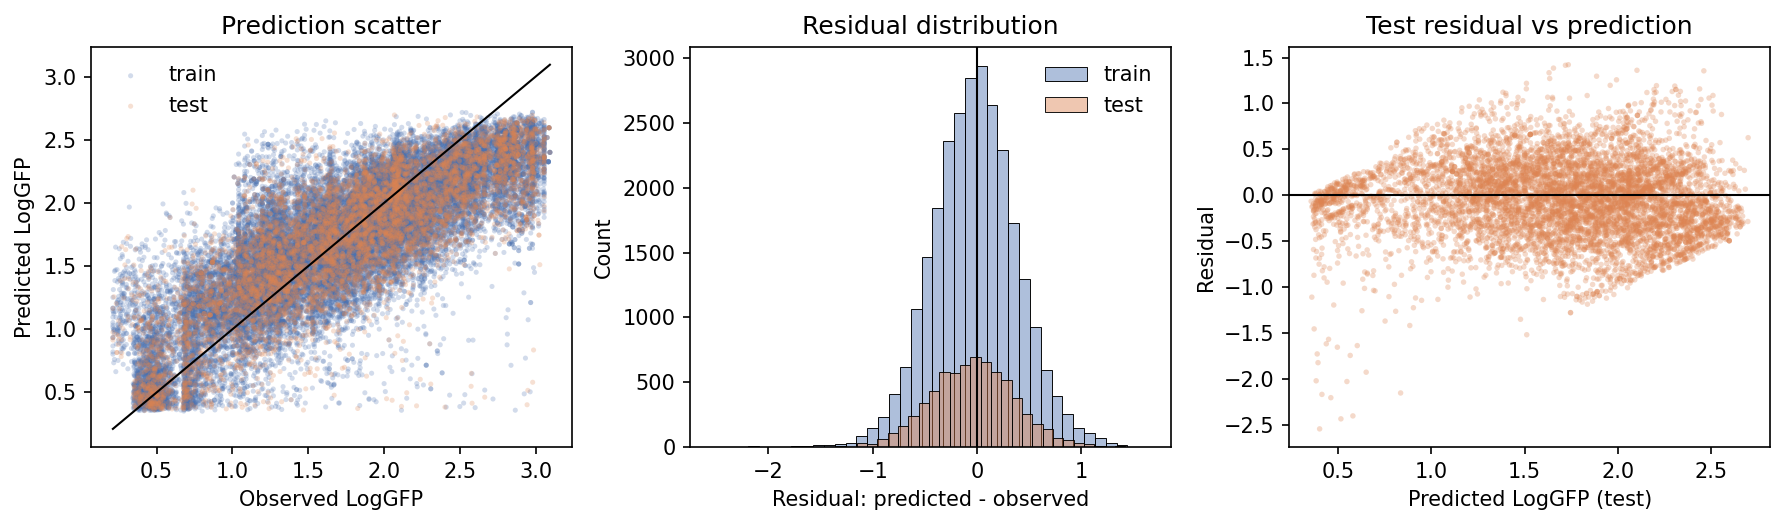

In [7]:
def predict_log10(seq_tensor, cond_tensor, batch_size=4096):
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, seq_tensor.shape[0], batch_size):
            pred = model(seq_tensor[start:start + batch_size], cond_tensor[start:start + batch_size]) / np.log(10)
            preds.append(pred.detach().cpu().numpy().ravel())
    return np.concatenate(preds)


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residual = y_pred - y_true
    mse = np.mean(residual ** 2)
    ss_res = np.sum(residual ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return {
        'n': len(y_true),
        'mse_log10': mse,
        'rmse_log10': np.sqrt(mse),
        'mae_log10': np.mean(np.abs(residual)),
        'pearson_r': pearsonr(y_true, y_pred)[0],
        'spearman_rho': spearmanr(y_true, y_pred).correlation,
        'r2': 1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
        'residual_mean': np.mean(residual),
        'residual_sd': np.std(residual),
    }


y_train_log10 = y_train.detach().cpu().numpy().ravel() / np.log(10)
y_test_log10 = y_test.detach().cpu().numpy().ravel() / np.log(10)
train_pred_log10 = predict_log10(X_train_seq, X_train_conds)
test_pred_log10 = predict_log10(X_test_seq, X_test_conds)

metrics_df = pd.DataFrame([
    {'split': 'train', **regression_metrics(y_train_log10, train_pred_log10)},
    {'split': 'test', **regression_metrics(y_test_log10, test_pred_log10)},
])
print('Train/Test prediction metrics')
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), dpi=150)
for split_name, y_true, y_pred, color in [
    ('train', y_train_log10, train_pred_log10, '#4c72b0'),
    ('test', y_test_log10, test_pred_log10, '#dd8452'),
]:
    axes[0].scatter(y_true, y_pred, s=6, alpha=0.25, label=split_name, color=color, edgecolors='none')
xy_min = min(y_train_log10.min(), y_test_log10.min(), train_pred_log10.min(), test_pred_log10.min())
xy_max = max(y_train_log10.max(), y_test_log10.max(), train_pred_log10.max(), test_pred_log10.max())
axes[0].plot([xy_min, xy_max], [xy_min, xy_max], color='black', lw=1)
axes[0].set_xlabel('Observed LogGFP')
axes[0].set_ylabel('Predicted LogGFP')
axes[0].set_title('Prediction scatter')
axes[0].legend(frameon=False)

sns.histplot(train_pred_log10 - y_train_log10, bins=40, color='#4c72b0', alpha=0.45, label='train', ax=axes[1])
sns.histplot(test_pred_log10 - y_test_log10, bins=40, color='#dd8452', alpha=0.45, label='test', ax=axes[1])
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Residual: predicted - observed')
axes[1].set_title('Residual distribution')
axes[1].legend(frameon=False)

axes[2].scatter(test_pred_log10, test_pred_log10 - y_test_log10, s=7, alpha=0.3, color='#dd8452', edgecolors='none')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_xlabel('Predicted LogGFP (test)')
axes[2].set_ylabel('Residual')
axes[2].set_title('Test residual vs prediction')
plt.tight_layout()
plt.show()


## Library-wise evaluation

This is useful for checking whether one library is systematically over- or under-predicted.


,split,Library,n,mse_log10,rmse_log10,mae_log10,pearson_r,spearman_rho,r2,residual_mean,residual_sd
0,train,PL17,7986,0.1907,0.4367,0.3303,0.7915,0.8139,0.6204,-0.0435,0.4345
1,train,SL16,2403,0.1718,0.4145,0.3368,0.6201,0.6158,0.3835,-0.0092,0.4144
2,train,SL17,3198,0.1825,0.4273,0.3425,0.6931,0.6944,0.4491,-0.0427,0.4251
3,train,SL18,2396,0.1754,0.4188,0.3403,0.6858,0.6928,0.4631,0.0028,0.4188
4,train,DL,1620,0.0889,0.2981,0.2442,0.9261,0.9271,0.7987,-0.0125,0.2979
5,train,UL,4821,0.1130,0.3361,0.2625,0.6464,0.6718,0.4163,0.0028,0.3361
6,train,ITS,4776,0.1927,0.4390,0.3513,0.5877,0.5931,0.3443,-0.0177,0.4386
7,test,PL17,2014,0.2068,0.4547,0.3377,0.7730,0.7965,0.5888,-0.0637,0.4502
8,test,SL16,597,0.1858,0.4311,0.3525,0.6063,0.6003,0.3572,-0.0498,0.4282
9,test,SL17,802,0.1812,0.4256,0.3430,0.6740,0.6747,0.4290,-0.0457,0.4232


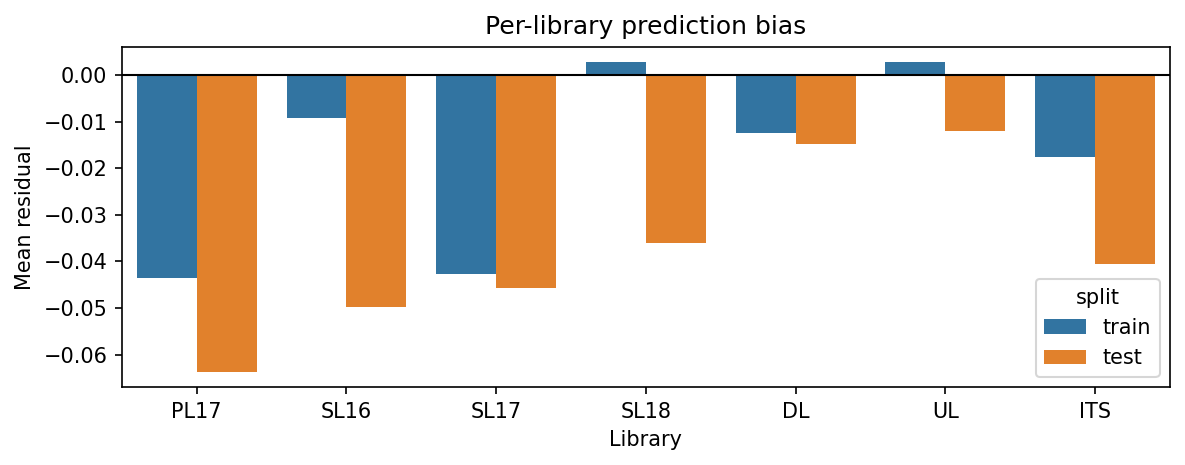

In [8]:
library_eval = []
for split_name, libs, y_true, y_pred in [
    ('train', library_train, y_train_log10, train_pred_log10),
    ('test', library_test, y_test_log10, test_pred_log10),
]:
    for lib in LIBRARY_ORDER:
        mask = libs == lib
        if mask.sum() == 0:
            continue
        library_eval.append({'split': split_name, 'Library': lib, **regression_metrics(y_true[mask], y_pred[mask])})

library_metrics_df = pd.DataFrame(library_eval)
display(library_metrics_df.round(4))

fig, ax = plt.subplots(figsize=(8, 3.2), dpi=150)
sns.barplot(data=library_metrics_df, x='Library', y='residual_mean', hue='split', order=LIBRARY_ORDER, ax=ax)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('Mean residual')
ax.set_title('Per-library prediction bias')
plt.tight_layout()
plt.show()


## Trained conv1 filter logos


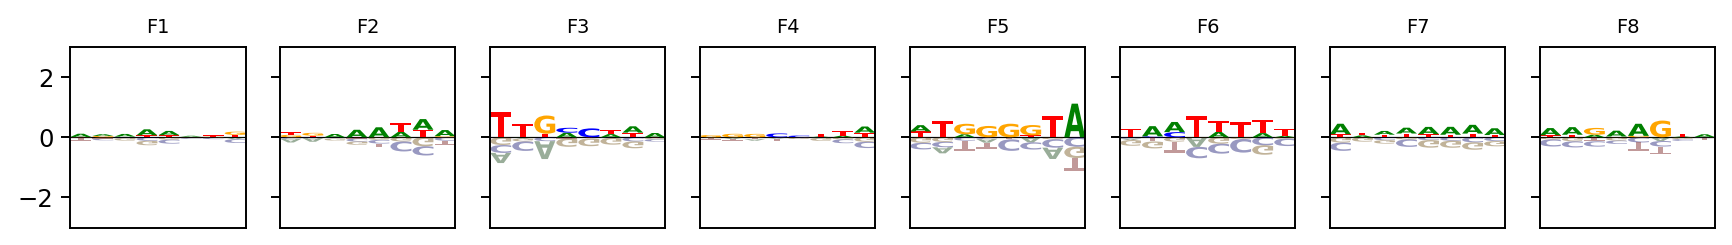

In [9]:
def show_logo(ax, pwm):
    color_scheme = {'A': 'green', 'C': 'blue', 'G': 'orange', 'T': 'red'}
    logomaker.Logo(
        pwm,
        shade_below=.6,
        fade_below=.6,
        font_name='DejaVu Sans',
        color_scheme=color_scheme,
        ax=ax,
    )


def conv1_weight_logo(filter_idx):
    pwm = pd.DataFrame(model.conv1.weight.detach().cpu().numpy()[filter_idx].T, columns=['A', 'C', 'G', 'T'])
    return pwm.sub(pwm.mean(axis=1), axis=0)

fig, axes = plt.subplots(1, 8, figsize=(10, 1.5), dpi=175, sharey=True)
for i, ax in enumerate(axes):
    show_logo(ax, conv1_weight_logo(i))
    ax.set_title(f'F{i + 1}', fontsize=8)
    ax.set_xticks([])
axes[0].set_ylim(-3, 3)
plt.tight_layout()
plt.savefig("../figures/Logo_CorePromoter_clean.svg")
plt.show()


## NN-based assembled-sequence scan

This scan uses the trained CorePromoter NN only. It does not use BPM.

Main columns in the output table:

- `design_arch_start`: expected architecture start inferred from designed m35 coordinate and model offset.
- `observed_arch_start`: best architecture start selected by conv2 over the full sequence.
- `arch_shift`: observed minus designed architecture start.
- `design_channel` / `observed_channel`: spacer architecture channel.
- `m10_shift`: derived coordinate shift after combining architecture shift and channel selection.
- `delta_model_log10`: best full-sequence score minus designed-position score.


UP: 5 variants; lengths=[19]
m35: 5 variants; lengths=[6]
spacer: 5 variants; lengths=[17]
m10: 4 variants; lengths=[6]
DIS: 5 variants; lengths=[8]
ITS: 5 variants; lengths=[10]

Combinations: 12,500
Sequence length range: 93-93 bp
Model architecture to m35 offset: 22

Off-design windows: 87.5%
Strong off-design windows: 8655/12500 = 69.2%


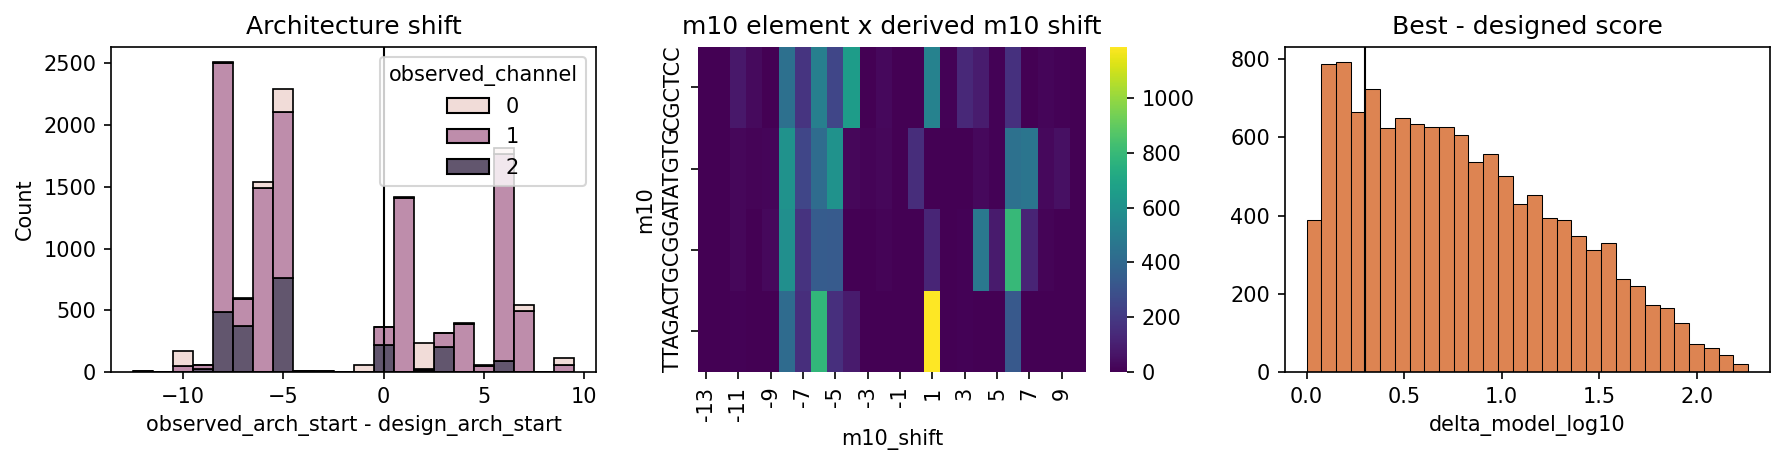

PermissionError: [Errno 13] Permission denied: '../tables/assembled_nn_scan_clean.csv'

In [10]:
SHARED_CSV = "../tables/elements_shared.csv"
OUT_CSV = "../tables/assembled_nn_scan_clean.csv"

BG5 = "AGGGAAGAGACC"
BG3 = "GTCGACTCTAGA"
LINKER = "CAC"

ORDER = ['UP', 'm35', 'spacer', 'm10', 'DIS', 'ITS']
SPACERS = [16, 17, 18]
SPACER_BY_CHANNEL = {ch: sp for ch, sp in enumerate(SPACERS)}
CHANNEL_BY_SPACER = {sp: ch for ch, sp in SPACER_BY_CHANNEL.items()}

M35_LEN = 6
M10_LEN = 6
POS_TOL = 2
MARGIN = 0.3
SCAN_BATCH_SIZE = 1024


def build_assembled_dataframe():
    dfc = pd.read_csv(SHARED_CSV)
    elems = {k: dfc[f'{k}_seq'].dropna().tolist() for k in ORDER}
    for k in ORDER:
        lengths = sorted({len(x) for x in elems[k]})
        print(f"{k}: {len(elems[k])} variants; lengths={lengths}")

    combos = list(itertools.product(*[elems[k] for k in ORDER]))
    df = pd.DataFrame(combos, columns=ORDER)
    df['Sequence'] = [BG5 + up + LINKER + m35 + sp + m10 + dis + its + BG3
                      for up, m35, sp, m10, dis, its in combos]
    df['design_m35_start'] = [len(BG5) + len(up) + len(LINKER) for up in df['UP']]
    df['design_spacer_len'] = df['spacer'].str.len()
    df['design_m10_start'] = df['design_m35_start'] + M35_LEN + df['design_spacer_len']
    df['design_channel'] = df['design_spacer_len'].map(CHANNEL_BY_SPACER)
    if df['design_channel'].isna().any():
        bad = sorted(df.loc[df['design_channel'].isna(), 'design_spacer_len'].unique())
        raise ValueError(f"Spacer lengths not supported by conv2 channels: {bad}")
    df['design_channel'] = df['design_channel'].astype(int)
    return df


def infer_model_m35_offset():
    conv2_w = model.conv2.weight.detach().cpu().numpy()
    conv2_m35_filter_idx = 2
    offsets = []
    for ch in range(conv2_w.shape[0]):
        nz = np.where(np.abs(conv2_w[ch, conv2_m35_filter_idx]) > 1e-6)[0]
        if len(nz) != 1:
            raise ValueError(f"Cannot infer unique m35 offset for conv2 channel {ch}: {nz}")
        offsets.append(int(nz[0]))
    if len(set(offsets)) != 1:
        print(f"Warning: channel-specific m35 offsets differ: {offsets}; using median.")
    return int(np.median(offsets))


def energy_to_log10(energy_tensor):
    return (model.energy2expression(energy_tensor.reshape(-1, 1)) / np.log(10)).detach().cpu().numpy().ravel()


def scan_corepromoter_model(df):
    model.eval()
    observed_arch_start = []
    observed_channel = []
    best_model_energy = []
    best_model_log10 = []
    design_model_energy = []
    design_model_log10 = []

    with torch.no_grad():
        for start in range(0, len(df), SCAN_BATCH_SIZE):
            sub = df.iloc[start:start + SCAN_BATCH_SIZE]
            x_np = np.array([dna_one_hot(seq) for seq in sub['Sequence']], dtype=np.float32)
            x = torch.tensor(x_np, dtype=torch.float32, device=device)

            conv2_out = model.conv2(model.conv1(x))
            n_channels = conv2_out.shape[1]
            n_pos = conv2_out.shape[2]
            flat = conv2_out.reshape(conv2_out.shape[0], -1)
            best_val, best_flat = flat.max(dim=1)
            best_ch = (best_flat // n_pos).detach().cpu().numpy().astype(int)
            best_pos = (best_flat % n_pos).detach().cpu().numpy().astype(int)

            observed_arch_start.extend(best_pos.tolist())
            observed_channel.extend(best_ch.tolist())
            best_model_energy.extend(best_val.detach().cpu().numpy().tolist())
            best_model_log10.extend(energy_to_log10(best_val).tolist())

            d_energy = np.full(len(sub), np.nan, dtype=float)
            d_log10 = np.full(len(sub), np.nan, dtype=float)
            valid_idx = []
            valid_vals = []
            for j, (_, row) in enumerate(sub.iterrows()):
                ch = int(row['design_channel'])
                pos = int(row['design_arch_start'])
                if 0 <= ch < n_channels and 0 <= pos < n_pos:
                    valid_idx.append(j)
                    valid_vals.append(conv2_out[j, ch, pos])
            if valid_vals:
                valid_tensor = torch.stack(valid_vals)
                valid_energy = valid_tensor.detach().cpu().numpy()
                valid_log10 = energy_to_log10(valid_tensor)
                for j, e, logv in zip(valid_idx, valid_energy, valid_log10):
                    d_energy[j] = float(e)
                    d_log10[j] = float(logv)

            design_model_energy.extend(d_energy.tolist())
            design_model_log10.extend(d_log10.tolist())

    out = df.copy()
    out['observed_arch_start'] = observed_arch_start
    out['observed_channel'] = observed_channel
    out['observed_spacer_len'] = out['observed_channel'].map(SPACER_BY_CHANNEL)
    out['arch_shift'] = out['observed_arch_start'] - out['design_arch_start']
    out['channel_shift'] = out['observed_channel'] - out['design_channel']
    out['observed_m35_start'] = out['observed_arch_start'] + out['model_m35_offset']
    out['observed_m10_start'] = out['observed_m35_start'] + M35_LEN + out['observed_spacer_len']
    out['m35_shift'] = out['observed_m35_start'] - out['design_m35_start']
    out['m10_shift'] = out['observed_m10_start'] - out['design_m10_start']
    out['best_model_energy'] = best_model_energy
    out['best_model_log10'] = best_model_log10
    out['design_model_energy'] = design_model_energy
    out['design_model_log10'] = design_model_log10
    out['delta_model_log10'] = out['best_model_log10'] - out['design_model_log10']
    out['off_design'] = (out['arch_shift'].abs() > POS_TOL) | (out['channel_shift'] != 0)
    out['strong_off_design'] = out['off_design'] & (out['delta_model_log10'] > MARGIN)
    return out


df_asm = build_assembled_dataframe()
model_m35_offset = infer_model_m35_offset()
df_asm['model_m35_offset'] = model_m35_offset
df_asm['design_arch_start'] = df_asm['design_m35_start'] - model_m35_offset

print()
print(f"Combinations: {len(df_asm):,}")
print(f"Sequence length range: {df_asm['Sequence'].str.len().min()}-{df_asm['Sequence'].str.len().max()} bp")
print(f"Model architecture to m35 offset: {model_m35_offset}")

scan_df = scan_corepromoter_model(df_asm)
print()
print(f"Off-design windows: {scan_df['off_design'].mean():.1%}")
print(f"Strong off-design windows: {scan_df['strong_off_design'].sum()}/{len(scan_df)} = {scan_df['strong_off_design'].mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), dpi=150)
sns.histplot(data=scan_df, x='arch_shift', hue='observed_channel', multiple='stack', discrete=True, ax=axes[0])
axes[0].axvline(0, color='black', lw=1)
axes[0].set_title('Architecture shift')
axes[0].set_xlabel('observed_arch_start - design_arch_start')

shift_tab = pd.crosstab(scan_df['m10'], scan_df['m10_shift'])
sns.heatmap(shift_tab, cmap='viridis', ax=axes[1])
axes[1].set_title('m10 element x derived m10 shift')
axes[1].set_xlabel('m10_shift')
axes[1].set_ylabel('m10')

axes[2].hist(scan_df['delta_model_log10'].dropna(), bins=30, color='#dd8452', edgecolor='black', lw=.5)
axes[2].axvline(MARGIN, color='black', lw=1)
axes[2].set_title('Best - designed score')
axes[2].set_xlabel('delta_model_log10')
plt.tight_layout()
plt.show()

scan_df.to_csv(OUT_CSV, index=False)
print(f"Saved {OUT_CSV}")
display(scan_df.head())


Delta summary: global-best - designed-position LogGFP


,count,mean,std,min,50%,75%,90%,95%,99%,max
delta_model_log10,12500.0,0.793,0.52,0.0,0.72,1.166,1.552,1.748,2.037,2.263


strong_off_design,False,True,All
off_design,,,
False,1559,0,1559
True,2286,8655,10941
All,3845,8655,12500


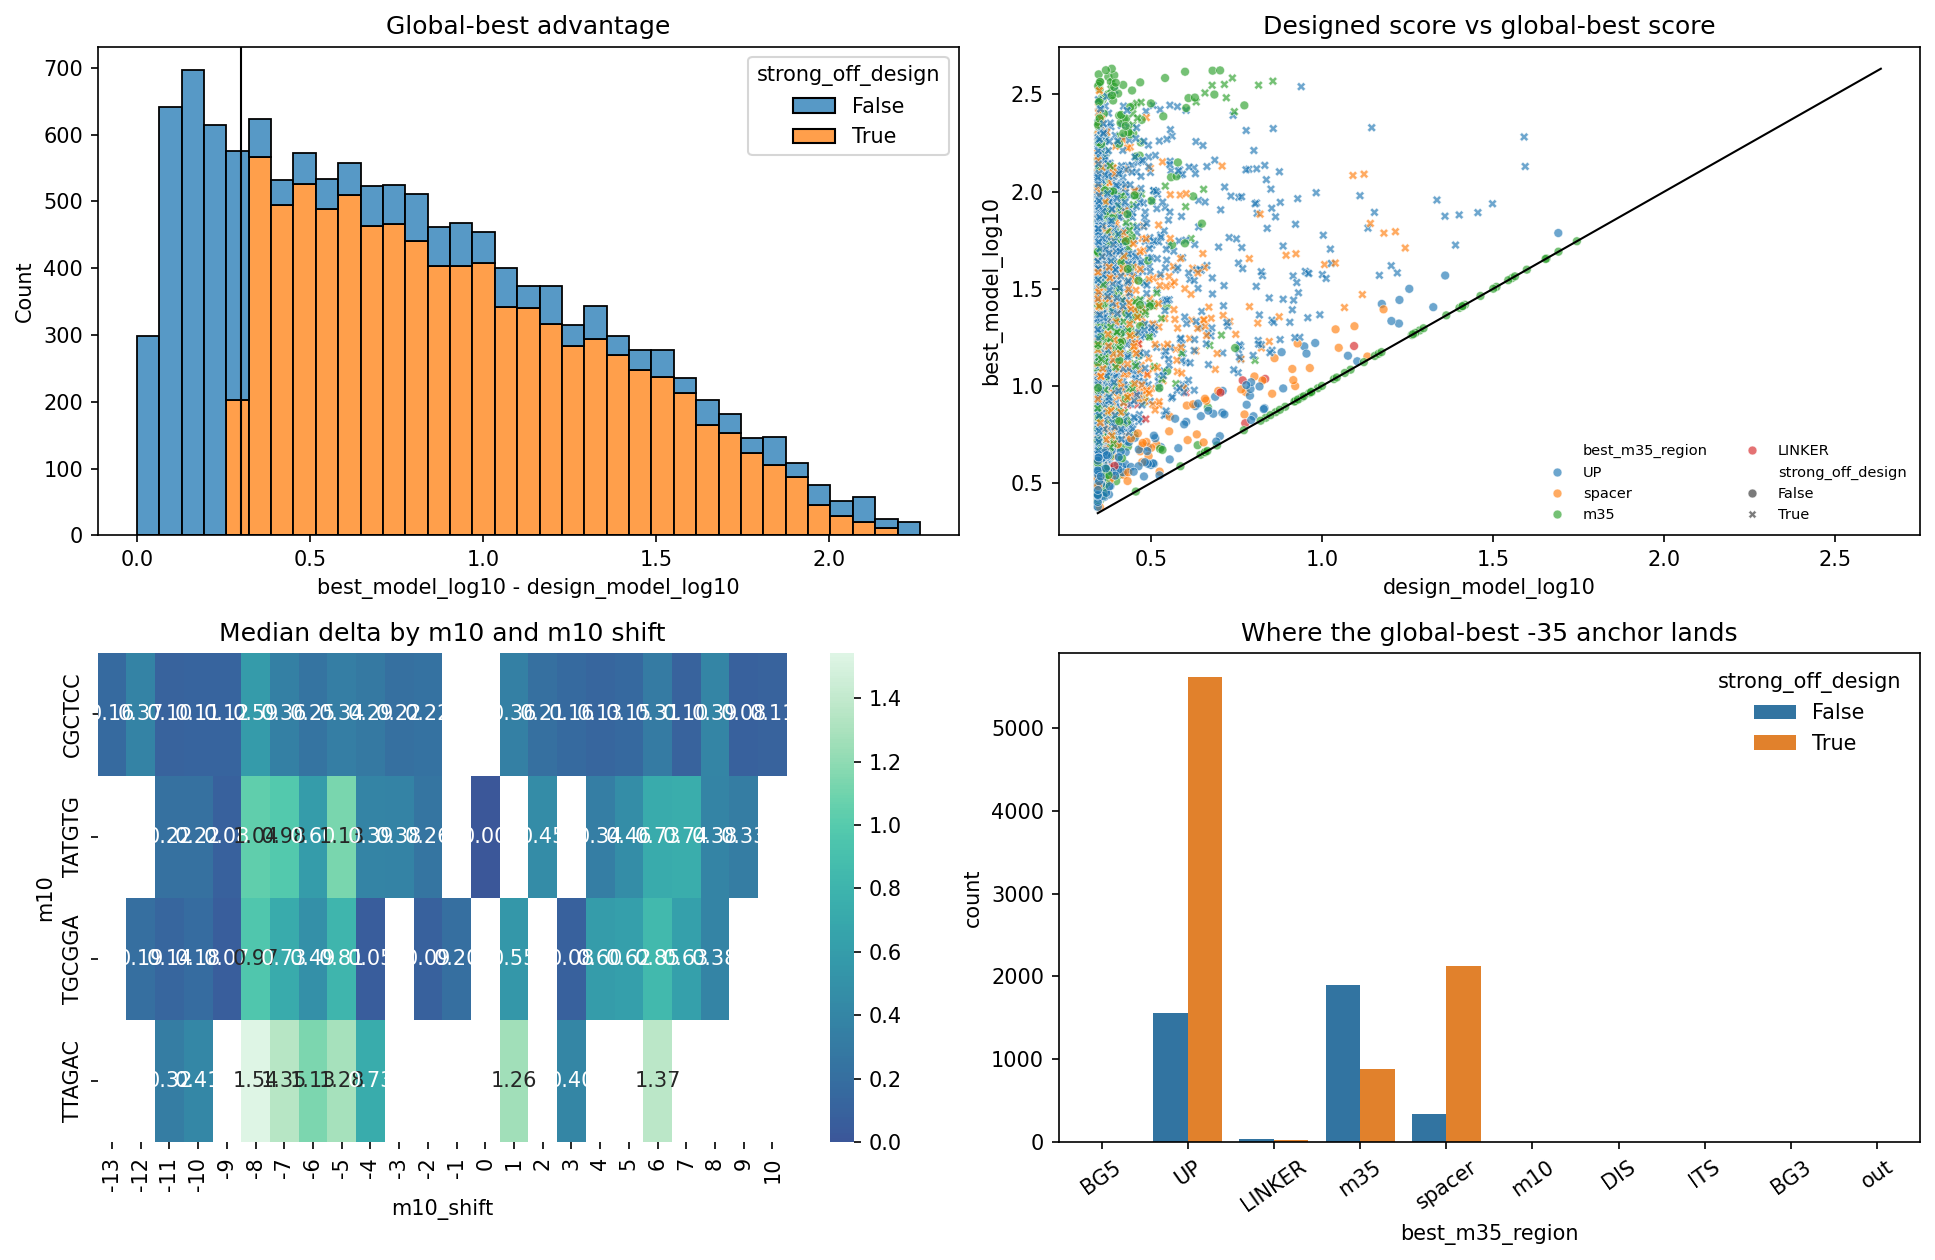

,best_m35_region,best_m10_region,strong_off_design,n,median_delta,median_arch_shift,median_m10_shift
3,UP,spacer,True,5619,0.913,-6.0,-6.0
7,spacer,DIS,True,2087,0.868,6.0,6.0
5,m35,m10,True,889,0.728,3.0,4.0
9,spacer,m10,True,38,0.550,6.0,5.0
1,LINKER,spacer,True,22,0.429,-1.0,-2.0
4,m35,m10,False,1896,0.684,1.0,1.0
2,UP,spacer,False,1563,0.169,-6.0,-6.0
6,spacer,DIS,False,334,0.195,6.0,6.0
0,LINKER,spacer,False,44,0.176,-1.0,-2.0
8,spacer,m10,False,8,0.214,6.0,5.0


,UP,m35,spacer,m10,DIS,ITS,design_model_log10,best_model_log10,delta_model_log10,arch_shift,channel_shift,m10_shift,best_m35_region,best_m10_region,design_core_seq,best_core_seq,design_context,best_context
9228,AGCTATCATATGGGTTGAC,ATACGC,TAATTCAACTAGGTCTG,TTAGAC,TTGAAGCT,TTGACCTGCA,0.348,2.611,2.263,1,0,1,m35,m10,ATACGCTAATTCAACTAGGTCTGTTAGAC,TACGCTAATTCAACTAGGTCTGTTAGACT,GACCACATACGCTAATTCAACTAGGTCTGTTAGACTTGAAG,ACCACATACGCTAATTCAACTAGGTCTGTTAGACTTGAAGC
9028,AGCTATCATATGGGTTGAC,ATACGC,TACGTACTTTGCATCGA,TTAGAC,TTGAAGCT,TTGACCTGCA,0.348,2.610,2.262,1,0,1,m35,m10,ATACGCTACGTACTTTGCATCGATTAGAC,TACGCTACGTACTTTGCATCGATTAGACT,GACCACATACGCTACGTACTTTGCATCGATTAGACTTGAAG,ACCACATACGCTACGTACTTTGCATCGATTAGACTTGAAGC
10528,TACCCTAACCTAATCGGTT,ATTACT,TACGTACTTTGCATCGA,TTAGAC,TTGAAGCT,TTGACCTGCA,0.368,2.625,2.257,1,0,1,m35,m10,ATTACTTACGTACTTTGCATCGATTAGAC,TTACTTACGTACTTTGCATCGATTAGACT,GTTCACATTACTTACGTACTTTGCATCGATTAGACTTGAAG,TTCACATTACTTACGTACTTTGCATCGATTAGACTTGAAGC
11728,TACCCTAACCTAATCGGTT,ATACGC,TAATTCAACTAGGTCTG,TTAGAC,TTGAAGCT,TTGACCTGCA,0.347,2.604,2.257,1,0,1,m35,m10,ATACGCTAATTCAACTAGGTCTGTTAGAC,TACGCTAATTCAACTAGGTCTGTTAGACT,GTTCACATACGCTAATTCAACTAGGTCTGTTAGACTTGAAG,TTCACATACGCTAATTCAACTAGGTCTGTTAGACTTGAAGC
10728,TACCCTAACCTAATCGGTT,ATTACT,TAATTCAACTAGGTCTG,TTAGAC,TTGAAGCT,TTGACCTGCA,0.370,2.626,2.256,1,0,1,m35,m10,ATTACTTAATTCAACTAGGTCTGTTAGAC,TTACTTAATTCAACTAGGTCTGTTAGACT,GTTCACATTACTTAATTCAACTAGGTCTGTTAGACTTGAAG,TTCACATTACTTAATTCAACTAGGTCTGTTAGACTTGAAGC
11528,TACCCTAACCTAATCGGTT,ATACGC,TACGTACTTTGCATCGA,TTAGAC,TTGAAGCT,TTGACCTGCA,0.347,2.602,2.256,1,0,1,m35,m10,ATACGCTACGTACTTTGCATCGATTAGAC,TACGCTACGTACTTTGCATCGATTAGACT,GTTCACATACGCTACGTACTTTGCATCGATTAGACTTGAAG,TTCACATACGCTACGTACTTTGCATCGATTAGACTTGAAGC
8028,AGCTATCATATGGGTTGAC,ATTACT,TACGTACTTTGCATCGA,TTAGAC,TTGAAGCT,TTGACCTGCA,0.382,2.631,2.250,1,0,1,m35,m10,ATTACTTACGTACTTTGCATCGATTAGAC,TTACTTACGTACTTTGCATCGATTAGACT,GACCACATTACTTACGTACTTTGCATCGATTAGACTTGAAG,ACCACATTACTTACGTACTTTGCATCGATTAGACTTGAAGC
8228,AGCTATCATATGGGTTGAC,ATTACT,TAATTCAACTAGGTCTG,TTAGAC,TTGAAGCT,TTGACCTGCA,0.385,2.633,2.248,1,0,1,m35,m10,ATTACTTAATTCAACTAGGTCTGTTAGAC,TTACTTAATTCAACTAGGTCTGTTAGACT,GACCACATTACTTAATTCAACTAGGTCTGTTAGACTTGAAG,ACCACATTACTTAATTCAACTAGGTCTGTTAGACTTGAAGC
8328,AGCTATCATATGGGTTGAC,ATTACT,TAATTCAACTAGGTCCA,TTAGAC,TTGAAGCT,TTGACCTGCA,0.355,2.575,2.220,1,0,1,m35,m10,ATTACTTAATTCAACTAGGTCCATTAGAC,TTACTTAATTCAACTAGGTCCATTAGACT,GACCACATTACTTAATTCAACTAGGTCCATTAGACTTGAAG,ACCACATTACTTAATTCAACTAGGTCCATTAGACTTGAAGC
11527,TACCCTAACCTAATCGGTT,ATACGC,TACGTACTTTGCATCGA,TTAGAC,TTGAAGCT,ATATCAGACC,0.375,2.591,2.216,1,0,1,m35,m10,ATACGCTACGTACTTTGCATCGATTAGAC,TACGCTACGTACTTTGCATCGATTAGACT,GTTCACATACGCTACGTACTTTGCATCGATTAGACTTGAAG,TTCACATACGCTACGTACTTTGCATCGATTAGACTTGAAGC


In [ ]:
# === Designed-position vs global-best score diagnostics ===
df_plot = scan_df.copy()

numeric_cols = [
    'design_m35_start', 'design_m10_start', 'observed_m35_start', 'observed_m10_start',
    'design_model_log10', 'best_model_log10', 'delta_model_log10',
    'arch_shift', 'm10_shift', 'channel_shift', 'observed_spacer_len',
]
for col in numeric_cols:
    if col in df_plot.columns:
        df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')


REGION_ORDER = ['BG5', 'UP', 'LINKER', 'm35', 'spacer', 'm10', 'DIS', 'ITS', 'BG3', 'out']


def _seq_value(row, col):
    val = row.get(col, '')
    return '' if pd.isna(val) else str(val)


def _region_intervals(row):
    parts = [
        ('BG5', BG5),
        ('UP', _seq_value(row, 'UP')),
        ('LINKER', LINKER),
        ('m35', _seq_value(row, 'm35')),
        ('spacer', _seq_value(row, 'spacer')),
        ('m10', _seq_value(row, 'm10')),
        ('DIS', _seq_value(row, 'DIS')),
        ('ITS', _seq_value(row, 'ITS')),
        ('BG3', BG3),
    ]
    intervals = []
    cursor = 0
    for name, seq in parts:
        end = cursor + len(seq)
        intervals.append((name, cursor, end))
        cursor = end
    return intervals


def _region_for_pos(row, pos):
    if pd.isna(pos):
        return 'out'
    pos = int(pos)
    for name, start, end in _region_intervals(row):
        if start <= pos < end:
            return name
    return 'out'


def _safe_slice(seq, start, end):
    if pd.isna(start) or pd.isna(end):
        return ''
    start = max(0, int(start))
    end = min(len(seq), int(end))
    return seq[start:end] if start < end else ''


df_plot['best_m35_region'] = df_plot.apply(lambda r: _region_for_pos(r, r['observed_m35_start']), axis=1)
df_plot['best_m10_region'] = df_plot.apply(lambda r: _region_for_pos(r, r['observed_m10_start']), axis=1)
df_plot['design_core_seq'] = df_plot.apply(
    lambda r: _safe_slice(r['Sequence'], r['design_m35_start'], r['design_m10_start'] + M10_LEN), axis=1
)
df_plot['best_core_seq'] = df_plot.apply(
    lambda r: _safe_slice(r['Sequence'], r['observed_m35_start'], r['observed_m10_start'] + M10_LEN), axis=1
)
df_plot['design_context'] = df_plot.apply(
    lambda r: _safe_slice(r['Sequence'], r['design_m35_start'] - 6, r['design_m10_start'] + M10_LEN + 6), axis=1
)
df_plot['best_context'] = df_plot.apply(
    lambda r: _safe_slice(r['Sequence'], r['observed_m35_start'] - 6, r['observed_m10_start'] + M10_LEN + 6), axis=1
)

print('Delta summary: global-best - designed-position LogGFP')
display(df_plot['delta_model_log10'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T.round(3))
display(pd.crosstab(df_plot['off_design'], df_plot['strong_off_design'], margins=True))

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), dpi=150)

sns.histplot(
    data=df_plot, x='delta_model_log10', hue='strong_off_design', bins=35,
    multiple='stack', ax=axes[0, 0]
)
axes[0, 0].axvline(MARGIN, color='black', lw=1)
axes[0, 0].set_title('Global-best advantage')
axes[0, 0].set_xlabel('best_model_log10 - design_model_log10')

sample_df = df_plot.sample(min(len(df_plot), 5000), random_state=SEED)
sns.scatterplot(
    data=sample_df, x='design_model_log10', y='best_model_log10',
    hue='best_m35_region', style='strong_off_design', s=18, alpha=0.65, ax=axes[0, 1]
)
lims = [
    min(df_plot['design_model_log10'].min(), df_plot['best_model_log10'].min()),
    max(df_plot['design_model_log10'].max(), df_plot['best_model_log10'].max()),
]
axes[0, 1].plot(lims, lims, color='black', lw=1)
axes[0, 1].set_title('Designed score vs global-best score')
axes[0, 1].legend(frameon=False, fontsize=7, ncol=2)

heat = pd.crosstab(
    df_plot['m10'], df_plot['m10_shift'],
    values=df_plot['delta_model_log10'], aggfunc='median'
)
sns.heatmap(heat, cmap='mako', center=MARGIN, annot=True, fmt='.2f', ax=axes[1, 0])
axes[1, 0].set_title('Median delta by m10 and m10 shift')
axes[1, 0].set_xlabel('m10_shift')
axes[1, 0].set_ylabel('m10')

sns.countplot(
    data=df_plot, x='best_m35_region', hue='strong_off_design',
    order=REGION_ORDER, ax=axes[1, 1]
)
axes[1, 1].set_title('Where the global-best -35 anchor lands')
axes[1, 1].set_xlabel('best_m35_region')
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].legend(frameon=False, title='strong_off_design')

plt.tight_layout()
plt.show()

region_summary = (
    df_plot.groupby(['best_m35_region', 'best_m10_region', 'strong_off_design'], dropna=False)
    .agg(
        n=('Sequence', 'size'),
        median_delta=('delta_model_log10', 'median'),
        median_arch_shift=('arch_shift', 'median'),
        median_m10_shift=('m10_shift', 'median'),
    )
    .reset_index()
    .sort_values(['strong_off_design', 'n', 'median_delta'], ascending=[False, False, False])
)
display(region_summary.head(20).round(3))

example_cols = [
    'UP', 'm35', 'spacer', 'm10', 'DIS', 'ITS',
    'design_model_log10', 'best_model_log10', 'delta_model_log10',
    'arch_shift', 'channel_shift', 'm10_shift',
    'best_m35_region', 'best_m10_region',
    'design_core_seq', 'best_core_seq', 'design_context', 'best_context',
]
top_examples = df_plot.sort_values('delta_model_log10', ascending=False).head(25)[example_cols]
display(top_examples.round(3))


## Anchor-pull replacement recommender

Lock one suspected design element sequence, test replacement candidates in all contexts where it appears, and export the ranked rescue table.


In [ ]:
# === Anchor-pull replacement recommender ===
import importlib
import anchor_pull_replacement

importlib.reload(anchor_pull_replacement)
from anchor_pull_replacement import suggest_replacements

# Change these two values to inspect another suspected driver.
element_type = "UP"
bad_seq = "AATCATGCAGGGTACGTTC"

replacement_result = suggest_replacements(
    scan_df=scan_df,
    element_type=element_type,
    bad_seq=bad_seq,
    scanner=scan_corepromoter_model,
    top_n=20,
    max_candidates=80,
    detail_top_n=10,
)

display(replacement_result.profile)
display(replacement_result.suggestions)
print(f"Saved {replacement_result.output_path}")


,metric,value
0,element_type,UP
1,locked_sequence,AATCATGCAGGGTACGTTC
2,contexts_found,2500
3,pull_m35_n,2281
4,pull_m35_rate,0.9124
5,pull_m10_n,2443
6,pull_m10_rate,0.9772
7,pull_both_n,2281
8,pull_both_rate,0.9124
9,pull_either_n,2443


,recommended_rank,candidate_seq,candidate_source_type,candidate_source_file,bin_id,same_bin,bin_distance,rank_in_bin,delta_epsilon,LogGFP,...,new_m10_shift_rate,same_landing_rate,median_delta_model_log10_after,mean_delta_model_log10_after,top_after_landing_group,top_after_landing_group_n,top_after_shifted_m35_seq,top_after_shifted_m35_n,top_after_shifted_m10_seq,top_after_shifted_m10_n
0,1,TCTAACTACTCTGAAATAA,candidates,candidates_UP.csv,4.0,False,NaN,13.0,0.706755,2.946209,...,0.8452,0.294310,0.371029,0.531945,m35@35_m10@58_sp17,559,TACGCT,169,TAGACT,238
1,2,CAAAACTACGGTGAATTAA,candidates,candidates_UP.csv,4.0,False,NaN,10.0,1.191626,2.961997,...,0.8976,0.355710,0.438976,0.557884,m35@35_m10@58_sp17,432,GTGAAT,279,TAGACT,215
2,3,ACTCGATCTTGGTAATTAA,candidates,candidates_UP.csv,4.0,False,NaN,7.0,0.803229,2.998876,...,0.9096,0.301678,0.442545,0.565225,m35@35_m10@58_sp17,461,ATTAAC,273,TAGACT,211
3,4,GTAAGTCACCCGTTAAAAG,candidates,candidates_UP.csv,5.0,False,NaN,5.0,2.081133,2.886729,...,0.9064,0.360213,0.353195,0.531428,m35@35_m10@58_sp17,730,TACGCT,174,TAGACT,225
4,5,TCAGGAAACATTCAAAATA,candidates,candidates_UP.csv,3.0,False,NaN,2.0,-0.093754,2.973915,...,0.9012,0.345068,0.591630,0.707765,m35@35_m10@58_sp17,811,TTCAAA,411,TAGACT,237
5,6,CATATCGTAGTGCAAATTA,candidates,candidates_UP.csv,4.0,False,NaN,16.0,0.531966,2.918930,...,0.9160,0.529677,0.494359,0.612942,m35@35_m10@58_sp17,444,TTACAC,318,TGCCAC,230
6,7,CAGAGTTTTCTGTTAATAG,candidates,candidates_UP.csv,5.0,False,NaN,3.0,1.769017,3.026843,...,0.9180,0.473598,0.497054,0.615567,m35@28_m10@51_sp17,623,TAGCAC,761,TGCCAC,347
7,8,TTCATAAACGTCTAAAAAC,candidates,candidates_UP.csv,4.0,False,NaN,11.0,0.805524,2.954893,...,0.9204,0.238641,0.468465,0.584896,m35@22_m10@44_sp16,437,TCTAAA,1018,TCAACT,237
8,9,CCCGGAATATGCTTATTAG,candidates,candidates_UP.csv,4.0,False,NaN,5.0,0.933975,3.029670,...,0.9212,0.417110,0.426386,0.547507,m35@34_m10@58_sp18,382,TAGCAC,290,TACGCC,230
9,10,TTACTGTACTTTCAAAAAC,candidates,candidates_UP.csv,4.0,False,NaN,6.0,1.231308,3.023020,...,0.9240,0.340974,0.414677,0.536156,m35@35_m10@58_sp17,427,TTCAAA,493,TAGACT,217


Saved C:\Users\kueih\OneDrive\桌面\Claude code\promoter library exp\outputs\019ec8ae-c0ac-7190-868c-5c4ba74a5396\replacement_UP_AATCATGCAGGGTACGTTC_20260615_140838.xlsx
